In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme()

In [183]:
#Загрузим данные и взглянем на них
data = pd.read_csv('Data.csv', parse_dates = ['Date'], sep=',', header=0)
data.sample(10)

,Date,Key_rate,Inflation,Money_M2,RUONIA
2949,2014-02-21,5.50,0.70,29861.2,6.25
1716,2019-02-26,7.75,0.44,45723.2,7.49
2241,2017-01-10,10.00,0.62,38417.7,9.93
2998,2013-12-05,5.50,0.51,28873.3,6.43
2624,2015-06-23,11.50,0.19,31820.4,11.99
989,2022-02-18,9.50,1.17,65310.3,9.54
2144,2017-06-02,9.25,0.61,39223.2,9.20
2072,2017-09-13,9.00,-0.15,39419.7,8.24
243,2025-02-28,21.00,0.81,116577.8,21.17
2171,2017-04-21,9.75,0.33,38555.5,9.55


В нашем датасете присутствуют следующие переменные: 
Date - дата в формате гггг.мм.дд.; 
Key_rate - значение ключевой ставки ЦБ РФ на данную дату в %; 
Inflation - темп прироста инфляции, конец месяца, соответствующего данной дате к концу предыдущего месяца; 
Money_M2 - денежный агрегат М2 на начало месяца, соответствующего данной дате, в млрд.руб;
RUONIA - значение ставки RUONIA, соответствующее данной дате, в %.
Источники - Центральный Банк Российской Федерации (https://www.cbr.ru/), Росстат (https://rosstat.gov.ru/statistics/price).

In [184]:
#Проверим отсутствие пропущенных значений
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3055 non-null   datetime64[ns]
 1   Key_rate   3055 non-null   float64       
 2   Inflation  3055 non-null   float64       
 3   Money_M2   3055 non-null   float64       
 4   RUONIA     3055 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 119.5 KB


In [185]:
#Посмотрим также на описательную статистику рассматриваемых показателей (кроме даты)
data.iloc[:, 1:].describe()

,Key_rate,Inflation,Money_M2,RUONIA
count,3055.000000,3055.000000,3055.000000,3055.000000
mean,10.200082,0.579316,60141.469951,10.134691
std,4.627709,0.777654,29104.754038,4.626089
min,4.250000,-0.540000,28276.400000,3.280000
25%,7.250000,0.280000,36145.600000,7.010000
50%,8.250000,0.460000,48267.000000,8.240000
75%,12.500000,0.740000,82221.700000,12.435000
max,21.000000,7.610000,129628.700000,28.650000


Построим графики ключевой ставки и ставки RUONIA. Довольно очевидно, что графики очень похожи и отличаются незначительно.

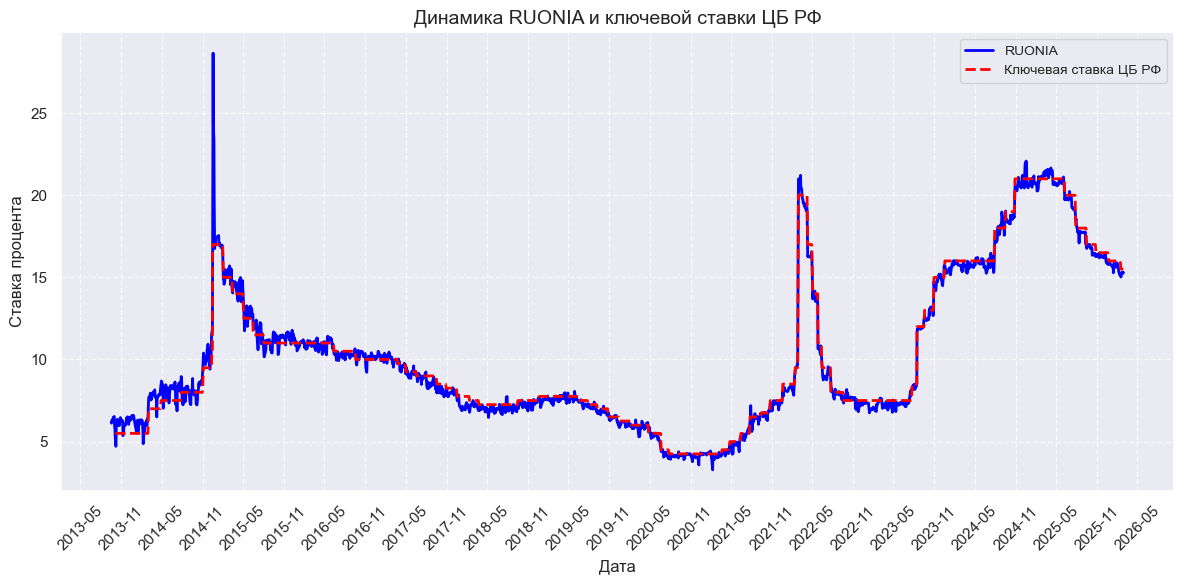

In [186]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(data['Date'], data['RUONIA'], label='RUONIA', linewidth=2, color='blue')
ax.plot(data['Date'], data['Key_rate'], label='Ключевая ставка ЦБ РФ', linewidth=2, color='red', linestyle='--')

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Ставка процента', fontsize=12)
ax.set_title('Динамика RUONIA и ключевой ставки ЦБ РФ', fontsize=14)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

ax.legend(fontsize=10, loc='best')

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

Также посмотрим на инфляцию. В целом, динамика схожа, однако абсолютного сходства нет.

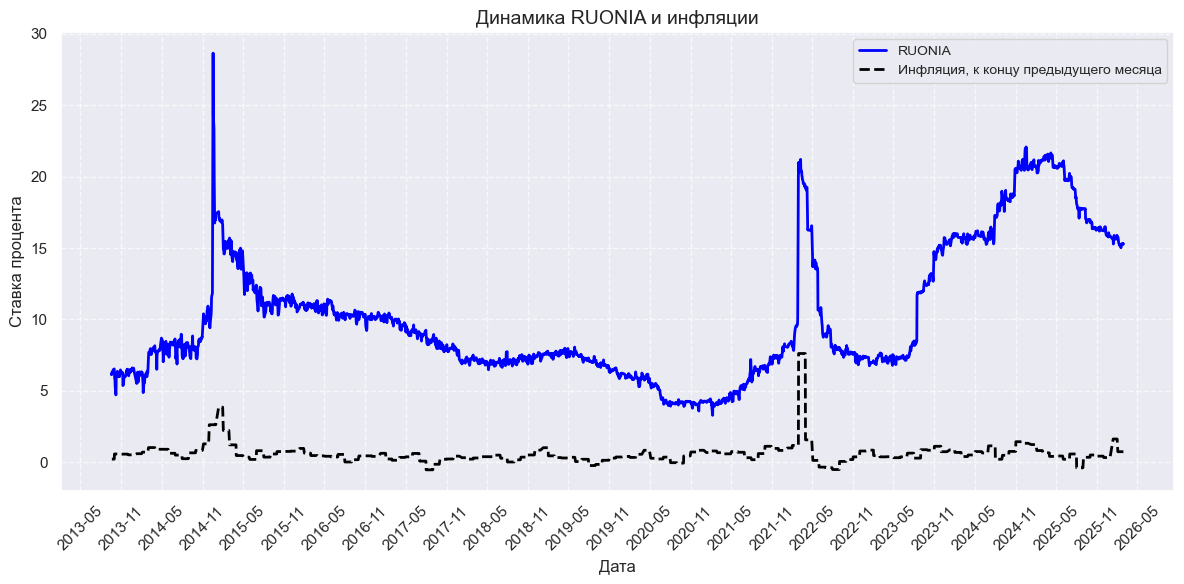

In [187]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(data['Date'], data['RUONIA'], label='RUONIA', linewidth=2, color='blue')
ax.plot(data['Date'], data['Inflation'], label='Инфляция, к концу предыдущего месяца', linewidth=2, color='black', linestyle='--')

ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Ставка процента', fontsize=12)
ax.set_title('Динамика RUONIA и инфляции', fontsize=14)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

ax.legend(fontsize=10, loc='best')

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

И, наконец, обратим внимание на графики денежной массы и RUONIA.

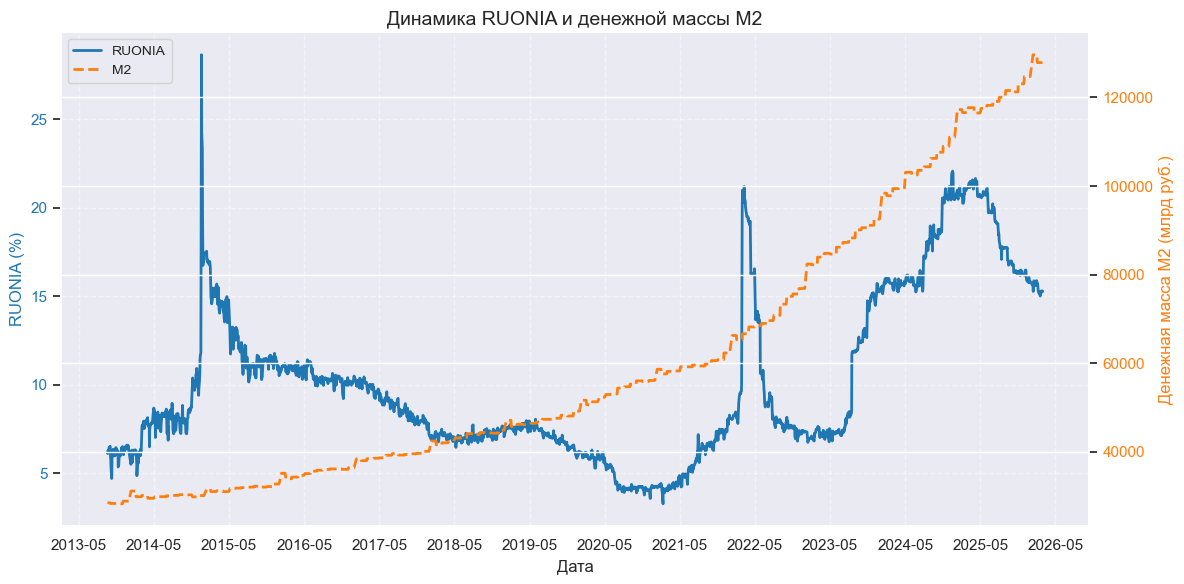

In [188]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('RUONIA (%)', color=color1, fontsize=12)
ax1.plot(data['Date'], data['RUONIA'], color=color1, linewidth=2, label='RUONIA')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Денежная масса M2 (млрд руб.)', color=color2, fontsize=12)
ax2.plot(data['Date'], data['Money_M2'], color=color2, linewidth=2, linestyle='--', label='M2')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.xticks(rotation=45)

plt.title('Динамика RUONIA и денежной массы M2', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()

plt.show()

Теперь проанализируем корреляцию между интересующей нас переменной RUONIA и инфляцией, ключевой ставкой, денежной массой (М2). При этом учтем, что инфляция дана - на конец месяца, а денежная масса - на начало.

In [189]:
import pandas as pd

df = data.copy()

df['YearMonth'] = df['Date'].dt.to_period('M')

last = df.groupby('YearMonth').last().reset_index()
last = last.rename(columns={
    'YearMonth': 'YearMonth_last',
    'RUONIA': 'RUONIA_end',
    'Key_rate': 'Key_rate_end',
    'Inflation': 'Inflation_end'
})

first = df.groupby('YearMonth').first().reset_index()
first = first.rename(columns={
    'YearMonth': 'YearMonth_first',
    'Money_M2': 'M2_start'
})
first['YearMonth_next'] = first['YearMonth_first'] + 1

monthly = last.merge(
    first[['YearMonth_next', 'M2_start']],
    left_on='YearMonth_last',
    right_on='YearMonth_next',
    how='left'
)

monthly_corr = monthly[['RUONIA_end', 'Key_rate_end', 'Inflation_end', 'M2_start']].copy()

corr_matrix = monthly_corr.corr()
print("Корреляция RUONIA (последний день месяца) с остальными переменными:")
print(corr_matrix['RUONIA_end'].drop('RUONIA_end').round(3))
print("\nПолная корреляционная матрица:")
print(corr_matrix.round(3))

monthly_data = monthly.copy()

Корреляция RUONIA (последний день месяца) с остальными переменными:
Key_rate_end     0.997
Inflation_end    0.320
M2_start         0.623
Name: RUONIA_end, dtype: float64

Полная корреляционная матрица:
               RUONIA_end  Key_rate_end  Inflation_end  M2_start
RUONIA_end          1.000         0.997          0.320     0.623
Key_rate_end        0.997         1.000          0.302     0.647
Inflation_end       0.320         0.302          1.000     0.023
M2_start            0.623         0.647          0.023     1.000


Поскольку мы имеем данные по инфляции и денежной массе лишь на конец и начало месяца соответственно, то попробуем исключить данные переменные и выполнить моделирование без них. Пока что проверим ряд на стационарность.

In [190]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

ruonia = data['RUONIA'].dropna()

adf_result = adfuller(ruonia, autolag='AIC')
print(f'ADF: статистика = {adf_result[0]:.4f}, p-value = {adf_result[1]:.4f}')
if adf_result[1] < 0.05:
    print('Ряд стационарен по ADF')
else:
    print('Ряд нестационарен по ADF (нужно дифференцирование)')

kpss_result = kpss(ruonia, regression='c', nlags='auto')
print(f'KPSS: статистика = {kpss_result[0]:.4f}, p-value = {kpss_result[1]:.4f}')
if kpss_result[1] > 0.05:
    print('Ряд стационарен по KPSS')
else:
    print('Ряд нестационарен по KPSS')

ADF: статистика = -2.0403, p-value = 0.2692
Ряд нестационарен по ADF (нужно дифференцирование)
KPSS: статистика = 2.6481, p-value = 0.0100
Ряд нестационарен по KPSS


In [191]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

ruonia = data['RUONIA'].dropna()

diff_ruonia = ruonia.diff().dropna()

adf_diff = adfuller(diff_ruonia, autolag='AIC')
print(f'ADF на разности: статистика = {adf_diff[0]:.4f}, p-value = {adf_diff[1]:.4f}')
if adf_diff[1] < 0.05:
    print('Ряд первых разностей стационарен по ADF')
else:
    print('Ряд первых разностей нестационарен по ADF')

kpss_diff = kpss(diff_ruonia, regression='c', nlags='auto')
print(f'KPSS на разности: статистика = {kpss_diff[0]:.4f}, p-value = {kpss_diff[1]:.4f}')
if kpss_diff[1] > 0.05:
    print('Ряд первых разностей стационарен по KPSS')
else:
    print('Ряд первых разностей нестационарен по KPSS')

ADF на разности: статистика = -10.0868, p-value = 0.0000
Ряд первых разностей стационарен по ADF
KPSS на разности: статистика = 0.0533, p-value = 0.1000
Ряд первых разностей стационарен по KPSS


Ряд стационарен в первых разностях. Воспользуемся AUTO-ARIMA для подбора лучшей модели.

Обучающая выборка: 2750 дней, тестовая: 305 дней

Лучшая модель: ARIMA(1, 1, 3) с AIC = 82.18
                               SARIMAX Results                                
Dep. Variable:                 RUONIA   No. Observations:                 2750
Model:                 ARIMA(1, 1, 3)   Log Likelihood                 -35.091
Date:                Mon, 23 Mar 2026   AIC                             82.183
Time:                        01:12:26   BIC                            117.697
Sample:                             0   HQIC                            95.014
                               - 2750                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Key_rate       0.9650      0.008    118.712      0.000       0.949       0.981
ar.L1          0.6961      0.010     

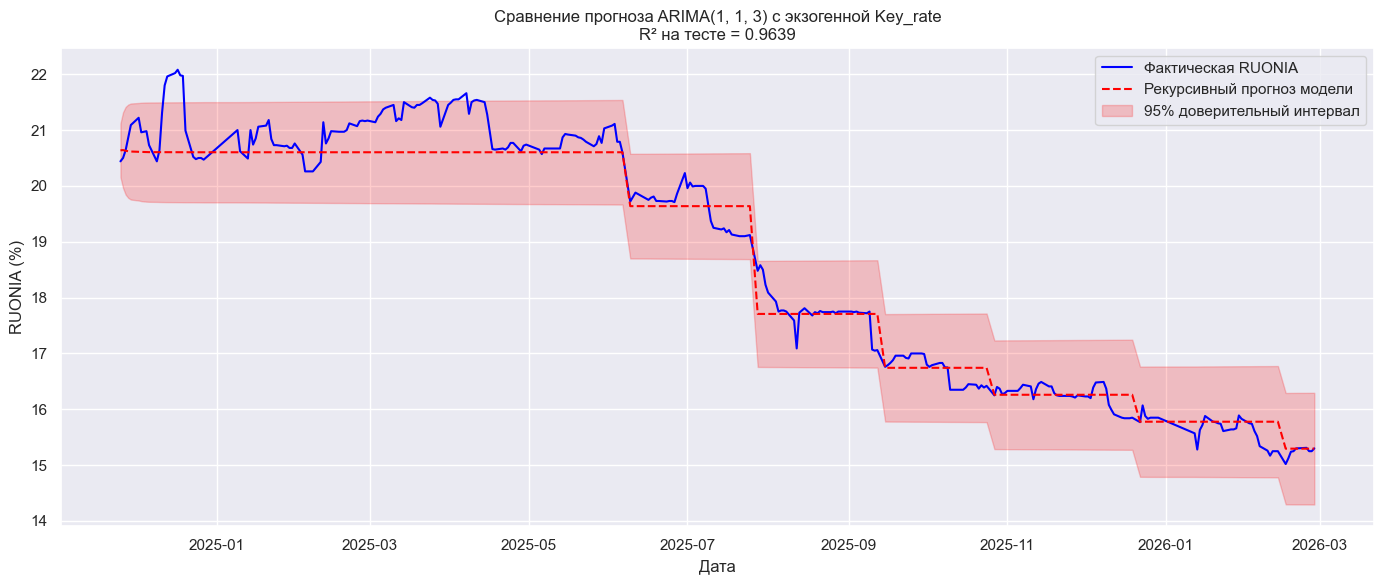

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score
import itertools

df = data[['Date', 'RUONIA', 'Key_rate']].copy()
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

test_size = int(len(df) * 0.1)
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print(f"Обучающая выборка: {len(train)} дней, тестовая: {len(test)} дней")

y_train = train['RUONIA']
X_train = train[['Key_rate']]

best_aic = np.inf
best_order = None
best_model = None

p_range = range(0, 4)
q_range = range(0, 4)

for p, q in itertools.product(p_range, q_range):
    try:
        model = ARIMA(y_train, exog=X_train, order=(p, 1, q))
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = (p, 1, q)
            best_model = res
    except:
        continue

print(f"\nЛучшая модель: ARIMA{best_order} с AIC = {best_aic:.2f}")
print(best_model.summary())

X_test = test[['Key_rate']]
forecast_result = best_model.get_forecast(steps=len(test), exog=X_test, dynamic=True)
pred_mean = forecast_result.predicted_mean
pred_ci = forecast_result.conf_int()

test = test.copy()
test['Predicted_RUONIA'] = pred_mean.values
test['Lower_CI'] = pred_ci.iloc[:, 0].values
test['Upper_CI'] = pred_ci.iloc[:, 1].values

r2 = r2_score(test['RUONIA'], test['Predicted_RUONIA'])
print(f"\nR² на тестовой выборке (рекурсивный прогноз): {r2:.4f}")

plt.figure(figsize=(14,6))
plt.plot(test['Date'], test['RUONIA'], label='Фактическая RUONIA', color='blue', linewidth=1.5)
plt.plot(test['Date'], test['Predicted_RUONIA'], label='Рекурсивный прогноз модели', color='red', linestyle='--', linewidth=1.5)
plt.fill_between(test['Date'], test['Lower_CI'], test['Upper_CI'], color='red', alpha=0.2, label='95% доверительный интервал')
plt.xlabel('Дата')
plt.ylabel('RUONIA (%)')
plt.title(f'Сравнение прогноза ARIMA{best_order} с экзогенной Key_rate\nR² на тесте = {r2:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Мы получили высокий показатель R-квадрат. Оптимальной оказалась модель ARIMA(1, 1, 3). Итоговая модель - SARIMAX, поскольку мы также используем экзогенную переменную.
    Попробуем составить прогноз вплоть до 10 апреля 2026 года на основе построенной модели. Также построим доверительные интервалы на уровне 95%.

                               SARIMAX Results                                
Dep. Variable:                 RUONIA   No. Observations:                 3061
Model:                 ARIMA(1, 1, 3)   Log Likelihood                  31.240
Date:                Mon, 23 Mar 2026   AIC                            -50.481
Time:                        01:12:28   BIC                            -14.324
Sample:                             0   HQIC                           -37.488
                               - 3061                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Key_rate       0.9594      0.008    125.197      0.000       0.944       0.974
ar.L1          0.7003      0.010     69.278      0.000       0.680       0.720
ma.L1         -0.7019      0.011    -64.164      0.0

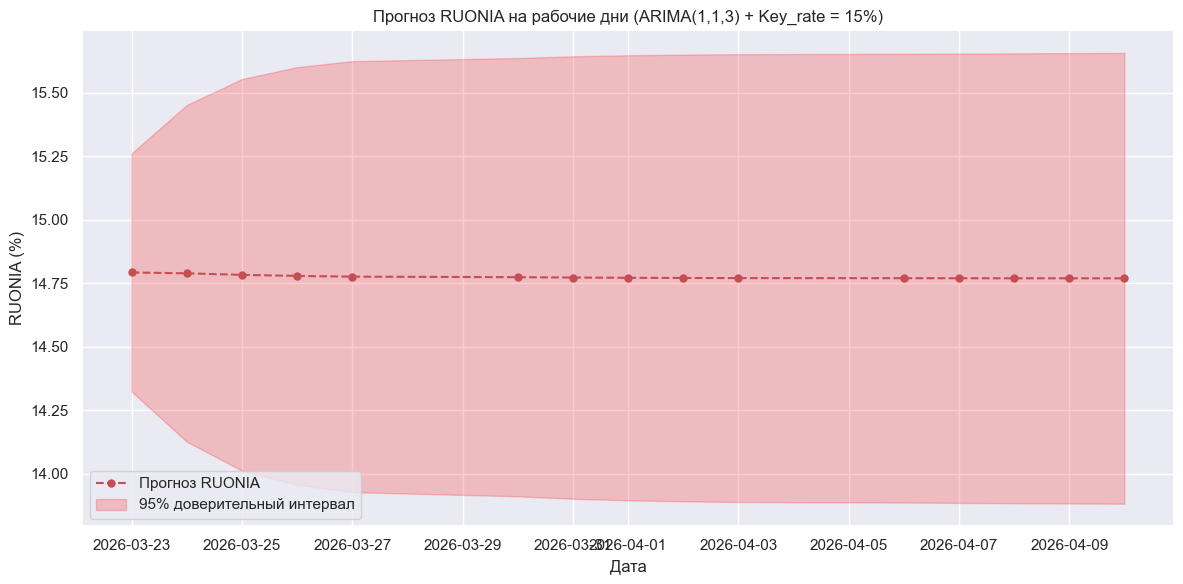

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

data = pd.read_csv('Data.csv', parse_dates=['Date'])

new_data = pd.DataFrame({
    'Date': pd.to_datetime(['2026-03-12', '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19']),
    'RUONIA': [14.96, 14.85, 14.81, 14.76, 14.76, 14.79],
    'Key_rate': [15.0, 15.0, 15.0, 15.0, 15.0, 15.0]
})
data = pd.concat([data, new_data], ignore_index=True).sort_values('Date').reset_index(drop=True)

df = data[['Date', 'RUONIA', 'Key_rate']].copy()
df = df.dropna().reset_index(drop=True)

y = df['RUONIA']
X = df[['Key_rate']]
model = ARIMA(y, exog=X, order=(1,1,3))
results = model.fit()
print(results.summary())

forecast_start = '2026-03-23'
forecast_end = '2026-04-10'
forecast_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='B')
forecast_steps = len(forecast_dates)

future_exog = pd.DataFrame({'Key_rate': [15.0] * forecast_steps})
forecast_result = results.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast_RUONIA': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
})
print("\nПрогноз RUONIA на рабочие дни:")
print(forecast_df.round(2))

plt.figure(figsize=(12,6))
plt.plot(forecast_df['Date'], forecast_df['Forecast_RUONIA'], 'ro--', label='Прогноз RUONIA', markersize=5)
plt.fill_between(forecast_df['Date'], forecast_df['Lower_CI'], forecast_df['Upper_CI'],
                 color='red', alpha=0.2, label='95% доверительный интервал')
plt.xlabel('Дата')
plt.ylabel('RUONIA (%)')
plt.title('Прогноз RUONIA на рабочие дни (ARIMA(1,1,3) + Key_rate = 15%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
